In [1]:
import sys
# umap-learn 0.5.x uses check_array(ensure_all_finite=...) which was removed in
# scikit-learn 1.8.0.  Pin to <1.8 so UMAP works, then restart the kernel.
# !{sys.executable} -m pip install "umap-learn>=0.5.7" "scikit-learn>=1.5,<1.8" -q
# print("Done -- restart the kernel before running the next cells.")

In [2]:
# ── Output directory ────────────────────────────────────────────────
# All plots, CSVs, and JSON files are saved here (created automatically).
OUTPUT_DIR = "results_holdout"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output folder: {OUTPUT_DIR}/")

Output folder: results_holdout/


In [3]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')

_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.manifold import trustworthiness
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, pairwise_distances)
from scipy.stats import spearmanr
import umap

import metric_functions as mf
if not hasattr(mf, 'ai_projection_mean_stable'):
    mf.ai_projection_mean_stable = mf.ai_projection_mean

from metric_functions import (
    stack_npp_to_ppn,
    compute_mean_projection,
    project_stack_to_tangent_features,
    compute_pairwise_distance_matrix,
)

DATA_DIR = "."
data = np.load(os.path.join(DATA_DIR, "covariance_matrices.npz"), allow_pickle=True)
X = data["X"]
y = data["y"]
meta = pd.read_csv(os.path.join(DATA_DIR, "metadata.csv"))
print(f"X shape : {X.shape}")
print(f"Classes : {np.unique(y).tolist()}")

idx_small = ((meta["sample"] == "sample_a") & (meta["scale"].isin([2, 6, 10]))).values
X_small, y_small = X[idx_small], y[idx_small]

idx_a = (meta["sample"] == "sample_a").values
X_a, y_a = X[idx_a], y[idx_a]

idx_ab = meta["sample"].isin(["sample_a", "sample_b"]).values
X_ab, y_ab = X[idx_ab], y[idx_ab]

X_full, y_full = X, y

print(f"\nSubset sizes -- small:{len(y_small)}  sample_a:{len(y_a)}  "
      f"ab:{len(y_ab)}  full:{len(y_full)}")

METRICS     = ["bw", "ai", "loge"]
# METRICS = ["loge"]
UMAP_PARAMS = dict(n_neighbors=15, min_dist=0.1, random_state=42)

X shape : (4752, 22, 22)
Classes : ['aluminium_foil', 'brown_bread', 'corduroy', 'cork', 'cotton', 'cracker', 'lettuce_leaf', 'linen', 'white_bread', 'wood', 'wool']

Subset sizes -- small:396  sample_a:1188  ab:2376  full:4752


## Task 1 — Manifold UMAP vs Tangent-Space UMAP

Computed on the full `X_small` (n=396) for visualization.

- **Manifold UMAP**: precomputed pairwise SPD distance matrix
- **Tangent-Space UMAP**: log-map vectors, Euclidean UMAP

Metrics: neighborhood overlap, trustworthiness, Spearman ρ.

In [4]:
# =============================================================================
# TASK 1 -- Manifold UMAP vs Tangent-Space UMAP
# =============================================================================
results_t1 = {}

for metric in METRICS:
    print(f"\n{'='*52}\n  {metric.upper()} geometry\n{'='*52}")

    print("  [A] Computing pairwise distance matrix ...", flush=True)
    D = compute_pairwise_distance_matrix(X_small, metric=metric, verbose=False)
    print(f"      D shape={D.shape}  max={D.max():.4f}  "
          f"symmetry_err={np.max(np.abs(D - D.T)):.2e}")

    print("  [A] Running UMAP(metric='precomputed') ...", flush=True)
    emb_manifold = umap.UMAP(metric="precomputed", **UMAP_PARAMS).fit_transform(D)

    print("  [B] Computing barycenter ...", flush=True)
    X_ppn   = stack_npp_to_ppn(X_small)
    M, info = compute_mean_projection(X_ppn, metric=metric)
    print(f"      converged: iters={info['iters']}  final_dist={info['final']:.2e}")

    print("  [B] Projecting to tangent space ...", flush=True)
    Z = project_stack_to_tangent_features(X_small, M, metric=metric)
    print(f"      Z shape={Z.shape}")

    print("  [B] Running UMAP(metric='euclidean') ...", flush=True)
    emb_tangent = umap.UMAP(metric="euclidean", **UMAP_PARAMS).fit_transform(Z)

    results_t1[metric] = {
        "D": D, "M": M, "Z": Z,
        "emb_manifold": emb_manifold,
        "emb_tangent":  emb_tangent,
    }
    print("  Done.")

print("\n\u2713  Task 1 computations complete.")


  BW geometry
  [A] Computing pairwise distance matrix ...
      D shape=(396, 396)  max=2.5277  symmetry_err=0.00e+00
  [A] Running UMAP(metric='precomputed') ...
  [B] Computing barycenter ...
      converged: iters=500  final_dist=4.53e-03
  [B] Projecting to tangent space ...
      Z shape=(396, 253)
  [B] Running UMAP(metric='euclidean') ...
  Done.

  AI geometry
  [A] Computing pairwise distance matrix ...
      D shape=(396, 396)  max=16.2767  symmetry_err=0.00e+00
  [A] Running UMAP(metric='precomputed') ...
  [B] Computing barycenter ...
      converged: iters=4  final_dist=2.44e+00
  [B] Projecting to tangent space ...
      Z shape=(396, 253)
  [B] Running UMAP(metric='euclidean') ...
  Done.

  LOGE geometry
  [A] Computing pairwise distance matrix ...
      D shape=(396, 396)  max=8.9764  symmetry_err=0.00e+00
  [A] Running UMAP(metric='precomputed') ...
  [B] Computing barycenter ...
      converged: iters=0  final_dist=0.00e+00
  [B] Projecting to tangent space ...
   

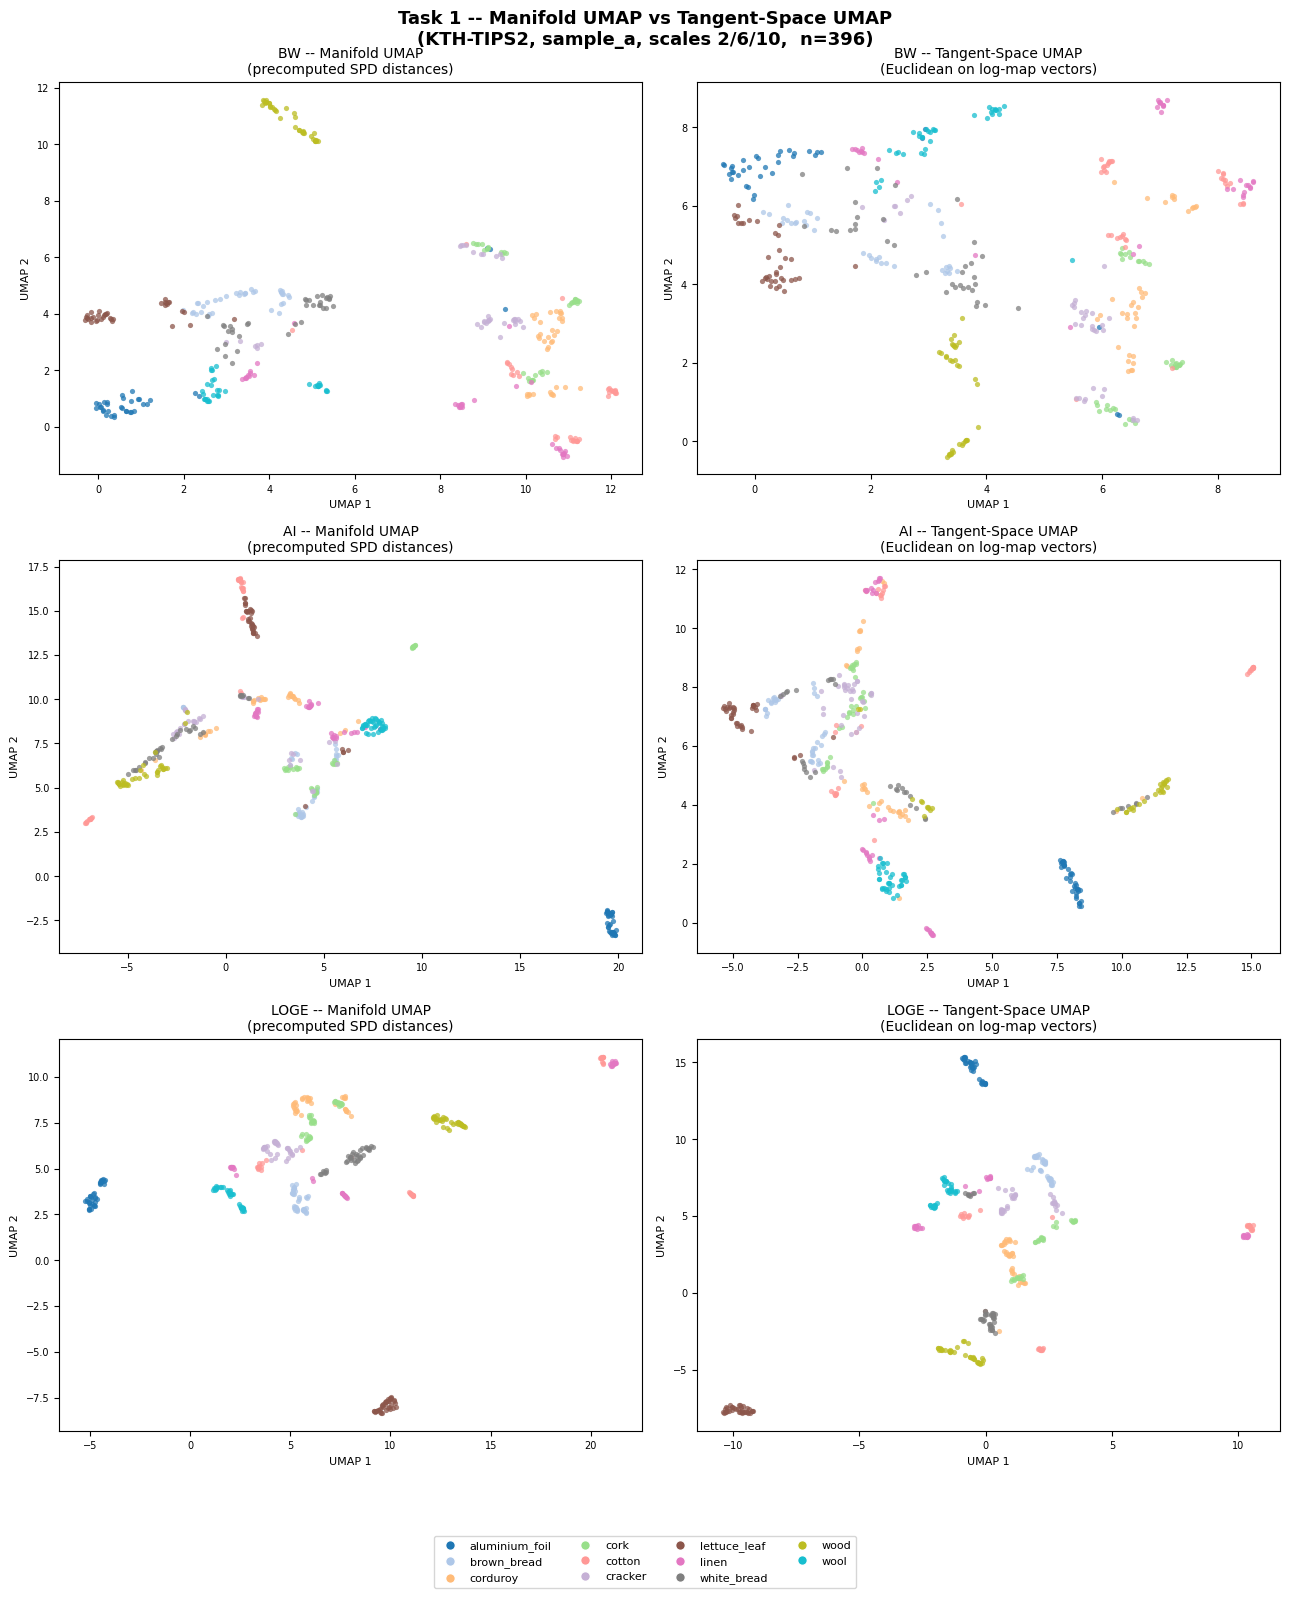

Saved: results_holdout/task1_umap_comparison.png


In [5]:
# Task 1 -- Plot: 3x2 UMAP grid -----------------------------------------------
label_set = np.unique(y_small)
cmap      = plt.cm.tab20
colors    = {lbl: cmap(i / len(label_set)) for i, lbl in enumerate(label_set)}

fig, axes = plt.subplots(3, 2, figsize=(13, 16))
fig.suptitle(
    "Task 1 -- Manifold UMAP vs Tangent-Space UMAP\n"
    "(KTH-TIPS2, sample_a, scales 2/6/10,  n=396)",
    fontsize=13, fontweight="bold")

for row, metric in enumerate(METRICS):
    for col, (key, title) in enumerate([
            ("emb_manifold", "Manifold UMAP\n(precomputed SPD distances)"),
            ("emb_tangent",  "Tangent-Space UMAP\n(Euclidean on log-map vectors)")]):
        ax  = axes[row, col]
        emb = results_t1[metric][key]
        for lbl in label_set:
            mask = y_small == lbl
            ax.scatter(emb[mask, 0], emb[mask, 1],
                       color=colors[lbl], label=lbl, s=14, alpha=0.75, linewidths=0)
        ax.set_title(f"{metric.upper()} -- {title}", fontsize=10)
        ax.set_xlabel("UMAP 1", fontsize=8)
        ax.set_ylabel("UMAP 2", fontsize=8)
        ax.tick_params(labelsize=7)

handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=colors[l], markersize=7, label=l)
    for l in label_set
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.01), frameon=True)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "task1_umap_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/task1_umap_comparison.png")

In [6]:
# Task 1 -- Metrics -----------------------------------------------------------
def neighborhood_overlap(D_manifold, Z_tangent, k=15):
    nn_m = NearestNeighbors(n_neighbors=k+1, metric="precomputed").fit(D_manifold)
    nn_t = NearestNeighbors(n_neighbors=k+1, metric="euclidean").fit(Z_tangent)
    _, idx_m = nn_m.kneighbors(D_manifold)
    _, idx_t = nn_t.kneighbors(Z_tangent)
    return float(np.mean([
        len(set(idx_m[i, 1:]) & set(idx_t[i, 1:])) / k
        for i in range(len(Z_tangent))
    ]))

def spearman_dist_corr(D_manifold, Z_tangent):
    n   = D_manifold.shape[0]
    tri = np.triu_indices(n, k=1)
    rho, _ = spearmanr(D_manifold[tri], pairwise_distances(Z_tangent)[tri])
    return float(rho)

K = 15
print(f"Task 1 -- Neighborhood Preservation Metrics  (k={K})\n")
print(f"{'Geometry':<10}  {'Nbr Overlap':>12}  {'Trustworthiness':>16}  {'Spearman rho':>12}")
print("-" * 57)
t1_metrics = {}
for metric in METRICS:
    D  = results_t1[metric]["D"]
    Z  = results_t1[metric]["Z"]
    no = neighborhood_overlap(D, Z, k=K)
    tw = trustworthiness(D, Z, n_neighbors=K, metric="precomputed")
    sp = spearman_dist_corr(D, Z)
    t1_metrics[metric] = {"nbr_overlap": no, "trustworthiness": tw, "spearman": sp}
    print(f"{metric.upper():<10}  {no:>12.4f}  {tw:>16.4f}  {sp:>12.4f}")

Task 1 -- Neighborhood Preservation Metrics  (k=15)

Geometry     Nbr Overlap   Trustworthiness  Spearman rho
---------------------------------------------------------
BW                0.8155            0.9950        0.9408
AI                0.5222            0.8603        0.6212
LOGE              0.9320            0.9995        0.9953


## Task 2 — Raw vs Standardized Tangent Features

**Q1** Feature scale comparison (boxplots of per-feature SDs)  
**Q2** PCA cumulative variance explained — raw vs standardized  
**Q3** Classification accuracy comparison → see Task 3 plots.

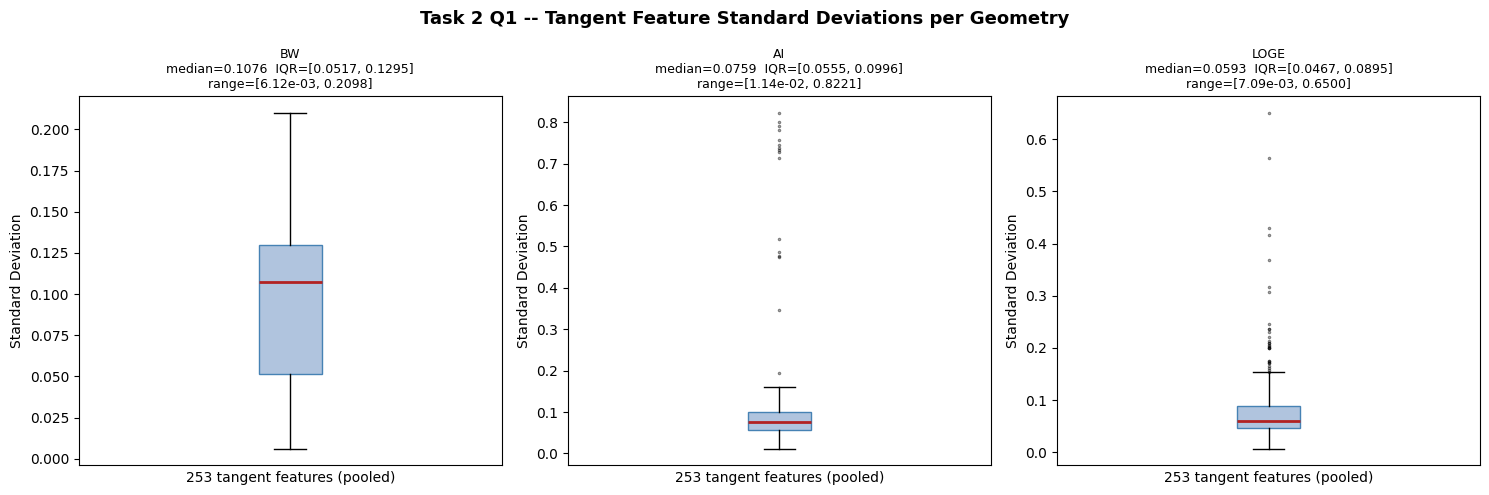

Saved: results_holdout/task2_feature_sds.png


In [7]:
# =============================================================================
# TASK 2 -- Raw vs Standardized Tangent Features
# =============================================================================
# Q1: Feature standard deviations per geometry

t2_data = {}
for metric in METRICS:
    Z = results_t1[metric]["Z"]
    t2_data[metric] = {"M": results_t1[metric]["M"], "Z": Z, "sds": Z.std(axis=0)}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Task 2 Q1 -- Tangent Feature Standard Deviations per Geometry",
             fontsize=13, fontweight="bold")
for ax, metric in zip(axes, METRICS):
    sds = t2_data[metric]["sds"]
    ax.boxplot(sds, vert=True, patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue", color="steelblue"),
               medianprops=dict(color="firebrick", linewidth=2),
               flierprops=dict(marker=".", markersize=3, alpha=0.5))
    ax.set_title(
        f"{metric.upper()}\nmedian={np.median(sds):.4f}  "
        f"IQR=[{np.percentile(sds,25):.4f}, {np.percentile(sds,75):.4f}]\n"
        f"range=[{sds.min():.2e}, {sds.max():.4f}]", fontsize=9)
    ax.set_ylabel("Standard Deviation")
    ax.set_xlabel("253 tangent features (pooled)")
    ax.set_xticks([])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task2_feature_sds.png"), dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/task2_feature_sds.png")

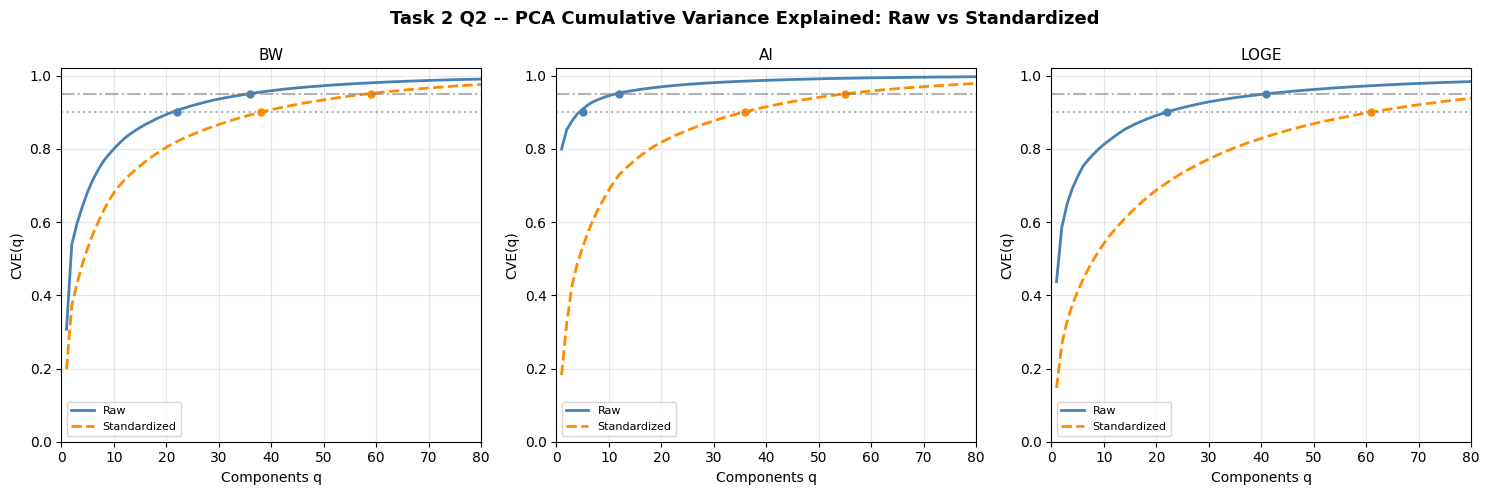

Saved: results_holdout/task2_pca_cve.png

Components needed to reach 90%/95% CVE:
Geometry   Raw@90%   Raw@95%   Std@90%   Std@95%
------------------------------------------------
BW              22        36        38        59
AI               5        12        36        55
LOGE            22        41        61        89


In [8]:
# Task 2 Q2 -- PCA cumulative variance explained ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Task 2 Q2 -- PCA Cumulative Variance Explained: Raw vs Standardized",
             fontsize=13, fontweight="bold")
n_feat  = 253
q_range = np.arange(1, n_feat + 1)
q_table = {}
for ax, metric in zip(axes, METRICS):
    Z_raw = t2_data[metric]["Z"]
    Z_std = StandardScaler().fit_transform(Z_raw)
    q_table[metric] = {}
    for Z, label, ls, col in [(Z_raw, "Raw", "-", "steelblue"),
                               (Z_std, "Standardized", "--", "darkorange")]:
        pca = PCA().fit(Z)
        cve = np.cumsum(pca.explained_variance_ratio_)
        ax.plot(q_range[:len(cve)], cve, ls, label=label, color=col, lw=2)
        for thresh in [0.90, 0.95]:
            idx_t = int(np.searchsorted(cve, thresh))
            if idx_t < len(cve):
                ax.plot(idx_t + 1, thresh, "o", color=col, markersize=5)
        tag = "raw" if label == "Raw" else "std"
        q_table[metric][tag] = {
            "q90": int(np.searchsorted(cve, 0.90)) + 1,
            "q95": int(np.searchsorted(cve, 0.95)) + 1,
        }
    ax.axhline(0.90, color="gray", linestyle=":", alpha=0.6)
    ax.axhline(0.95, color="gray", linestyle="-.", alpha=0.6)
    ax.set_title(f"{metric.upper()}", fontsize=11)
    ax.set_xlabel("Components q"); ax.set_ylabel("CVE(q)")
    ax.set_xlim(0, 80); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task2_pca_cve.png"), dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/task2_pca_cve.png\n")
print("Components needed to reach 90%/95% CVE:")
print(f"{'Geometry':<8}  {'Raw@90%':>8}  {'Raw@95%':>8}  {'Std@90%':>8}  {'Std@95%':>8}")
print("-" * 48)
for metric in METRICS:
    r = q_table[metric]["raw"]; s = q_table[metric]["std"]
    print(f"{metric.upper():<8}  {r['q90']:>8}  {r['q95']:>8}  {s['q90']:>8}  {s['q95']:>8}")

## Task 3 — Classification with 80/20 Holdout + 5-Fold CV

**Evaluation protocol:**

```
All data (X_use)
├── 20%  held-out test set  ← touched only once, final evaluation
└── 80%  training pool
         └── 5-fold stratified CV  ← model selection & CV metrics
```

For each fold and for the final model, all preprocessing steps (barycenter, scaler, DR) are fitted **exclusively on the training split**.

Results table reports both **CV accuracy** (mean ± std across 5 folds on 80%) and **holdout accuracy** (final model on the 20% test set).

In [9]:
# =============================================================================
# TASK 3 -- 80/20 Holdout Split
# =============================================================================
# One fixed stratified split applied to all geometries and pipelines.
# The 20% test set is never used during CV — only for the final evaluation.

X_use, y_use = X_small, y_small

le_use    = LabelEncoder()
y_enc_use = le_use.fit_transform(y_use)

X_train80, X_test20, y_train80, y_test20 = train_test_split(
    X_use, y_enc_use,
    test_size=0.2,
    stratify=y_enc_use,
    random_state=42,
)

print(f"Train (80%): {X_train80.shape[0]} samples")
print(f"Test  (20%): {X_test20.shape[0]}  samples")
print(f"\nClass distribution in train: {dict(zip(*np.unique(y_train80, return_counts=True)))}")
print(f"Class distribution in test:  {dict(zip(*np.unique(y_test20,  return_counts=True)))}")

Train (80%): 316 samples
Test  (20%): 80  samples

Class distribution in train: {np.int64(0): np.int64(29), np.int64(1): np.int64(29), np.int64(2): np.int64(29), np.int64(3): np.int64(28), np.int64(4): np.int64(29), np.int64(5): np.int64(29), np.int64(6): np.int64(28), np.int64(7): np.int64(28), np.int64(8): np.int64(29), np.int64(9): np.int64(29), np.int64(10): np.int64(29)}
Class distribution in test:  {np.int64(0): np.int64(7), np.int64(1): np.int64(7), np.int64(2): np.int64(7), np.int64(3): np.int64(8), np.int64(4): np.int64(7), np.int64(5): np.int64(7), np.int64(6): np.int64(8), np.int64(7): np.int64(8), np.int64(8): np.int64(7), np.int64(9): np.int64(7), np.int64(10): np.int64(7)}


In [10]:
# Task 3 -- Evaluation function (80% CV + holdout) ----------------------------

def _make_clf(name):
    if name == "knn":
        return KNeighborsClassifier(n_neighbors=5)
    if name == "svm":
        return SVC(kernel="rbf", C=1.0, probability=True)
    if name == "lr":
        return LogisticRegression(max_iter=1000, C=1.0,
                                  solver="lbfgs", multi_class="multinomial")
    raise ValueError(f"Unknown classifier: {name}")


def _tangent_pipeline(X_tr, X_te, metric, pipeline, q, standardize, random_state):
    """Shared helper: barycenter -> tangent -> optional scale -> optional DR."""
    M, _ = compute_mean_projection(stack_npp_to_ppn(X_tr), metric=metric)
    Z_tr = project_stack_to_tangent_features(X_tr, M, metric=metric)
    Z_te = project_stack_to_tangent_features(X_te, M, metric=metric)

    if standardize:
        sc   = StandardScaler()
        Z_tr = sc.fit_transform(Z_tr)
        Z_te = sc.transform(Z_te)

    if pipeline == "B":
        n_comp = min(q, Z_tr.shape[1], Z_tr.shape[0] - 1)
        dr     = PCA(n_components=n_comp, random_state=random_state)
        Z_tr   = dr.fit_transform(Z_tr)
        Z_te   = dr.transform(Z_te)
    elif pipeline == "C":
        dr   = umap.UMAP(n_components=q, metric="euclidean",
                         n_neighbors=min(15, len(Z_tr) - 1),
                         min_dist=0.1, random_state=random_state)
        Z_tr = dr.fit_transform(Z_tr)
        Z_te = dr.transform(Z_te)

    return Z_tr, Z_te


def _collect_metrics(clf, Z_te, y_te, n_cls):
    y_pred = clf.predict(Z_te)
    acc    = accuracy_score(y_te, y_pred)
    prec   = precision_score(y_te, y_pred, average="macro", zero_division=0)
    rec    = recall_score(y_te,    y_pred, average="macro", zero_division=0)
    y_prob = (clf.predict_proba(Z_te) if hasattr(clf, "predict_proba")
              else label_binarize(y_pred, classes=np.arange(n_cls)))
    try:
        auc = roc_auc_score(y_te, y_prob, multi_class="ovr",
                            average="macro", labels=np.arange(n_cls))
    except ValueError:
        auc = float("nan")
    return acc, prec, rec, auc


def run_holdout_cv(X_train, y_train, X_test, y_test,
                   metric, pipeline="A", q=10,
                   standardize=False, classifier="knn",
                   n_cv=5, random_state=42):
    """
    Step 1 — 5-fold CV on (X_train, y_train).
      Each fold: barycenter/scaler/DR fitted on the CV training split,
      applied to the CV validation split.  Reports mean CV metrics.

    Step 2 — Final model.
      Barycenter/scaler/DR fitted on all of X_train.
      Evaluated once on the held-out X_test (20%).
    """
    n_cls = len(np.unique(y_train))
    skf   = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=random_state)

    # ── Step 1: 5-fold CV on the 80% training set ────────────────────────────
    cv_accs, cv_precs, cv_recs, cv_aucs, cv_times = [], [], [], [], []

    for tr_idx, val_idx in skf.split(X_train, y_train):
        t0 = time.time()
        X_cv_tr,  X_cv_val  = X_train[tr_idx],  X_train[val_idx]
        y_cv_tr,  y_cv_val  = y_train[tr_idx],  y_train[val_idx]

        Z_tr, Z_val = _tangent_pipeline(X_cv_tr, X_cv_val,
                                        metric, pipeline, q, standardize, random_state)

        clf = _make_clf(classifier)
        clf.fit(Z_tr, y_cv_tr)

        acc, prec, rec, auc = _collect_metrics(clf, Z_val, y_cv_val, n_cls)
        cv_accs.append(acc); cv_precs.append(prec)
        cv_recs.append(rec); cv_aucs.append(auc)
        cv_times.append(time.time() - t0)

    # ── Step 2: refit on full 80%, evaluate on 20% holdout ───────────────────
    t0 = time.time()
    Z_tr_full, Z_te_full = _tangent_pipeline(X_train, X_test,
                                              metric, pipeline, q, standardize, random_state)
    clf_final = _make_clf(classifier)
    clf_final.fit(Z_tr_full, y_train)

    h_acc, h_prec, h_rec, h_auc = _collect_metrics(clf_final, Z_te_full, y_test, n_cls)
    holdout_time = time.time() - t0

    return {
        # CV metrics (5-fold on 80%)
        "cv_accuracy":  np.mean(cv_accs),
        "cv_acc_std":   np.std(cv_accs),
        "cv_precision": np.mean(cv_precs),
        "cv_recall":    np.mean(cv_recs),
        "cv_auc":       np.nanmean(cv_aucs),
        "cv_runtime_s": np.sum(cv_times),
        # Holdout metrics (final model on 20%)
        "ho_accuracy":  h_acc,
        "ho_precision": h_prec,
        "ho_recall":    h_rec,
        "ho_auc":       h_auc,
        "ho_runtime_s": holdout_time,
    }

print("run_holdout_cv() defined.")

run_holdout_cv() defined.


In [11]:
# Task 3 -- Run full comparison (parallel) ------------------------------------
from joblib import Parallel, delayed

Q_VALUES    = [5, 10, 20]
CLASSIFIERS = ["knn", "svm", "lr"]

def single_run(X_train, y_train, X_test, y_test,
               metric, standardize, clf_name, pipe, pname, q):
    import sys, os, time as _time
    # ensure metric_functions is importable in worker process
    _root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
    if _root not in sys.path:
        sys.path.insert(0, _root)

    t = _time.time()
    r = run_holdout_cv(X_train, y_train, X_test, y_test,
                       metric=metric, pipeline=pipe, q=q,
                       standardize=standardize, classifier=clf_name)
    elapsed = _time.time() - t
    print(f"  done: {metric.upper()} std={standardize} {clf_name} {pname} "
          f"q={q}  cv={r['cv_accuracy']:.3f}  ho={r['ho_accuracy']:.3f}  "
          f"({elapsed:.1f}s)", flush=True)
    return {"geometry": metric.upper(), "pipeline": pname,
            "q": q, "standardize": standardize, "classifier": clf_name, **r}

# Build the flat jobs list
jobs = []
for metric in METRICS:
    for standardize in [False, True]:
        for clf_name in CLASSIFIERS:
            jobs.append((metric, standardize, clf_name, "A", "A-Full", None))
            for q in Q_VALUES:
                for pipe, pname in [("B", "B-PCA"), ("C", "C-UMAP")]:
                    jobs.append((metric, standardize, clf_name, pipe, pname, q))

print(f"Total jobs: {len(jobs)} -- running in parallel (n_jobs=-1)...")
rows = Parallel(n_jobs=-1, verbose=5)(
    delayed(single_run)(X_train80, y_train80, X_test20, y_test20, *job)
    for job in jobs
)

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(
    ["geometry", "classifier", "pipeline", "q"]).reset_index(drop=True)
df_results.to_csv(os.path.join(OUTPUT_DIR, "task3_holdout_results.csv"), index=False)

print("\n\n-- Task 3 Results (CV on 80% | Holdout on 20%) --")
display_cols = ["geometry", "pipeline", "q", "standardize", "classifier",
                "cv_accuracy", "cv_acc_std", "ho_accuracy",
                "ho_precision", "ho_recall", "ho_auc"]
print(df_results[display_cols].to_string(index=False,
      float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print("\nSaved: task3_holdout_results.csv")


Total jobs: 126 -- running in parallel (n_jobs=-1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed: 18.7min
[Parallel(n_jobs=-1)]: Done 109 out of 126 | elapsed: 34.4min remaining:  5.4min
[Parallel(n_jobs=-1)]: Done 126 out of 126 | elapsed: 34.7min finished




-- Task 3 Results (CV on 80% | Holdout on 20%) --
geometry pipeline       q  standardize classifier  cv_accuracy  cv_acc_std  ho_accuracy  ho_precision  ho_recall  ho_auc
      AI   A-Full     NaN        False        knn       0.8608      0.0394       0.9000        0.9116     0.8994  0.9880
      AI   A-Full     NaN         True        knn       0.8988      0.0276       0.9750        0.9773     0.9740  0.9926
      AI    B-PCA  5.0000        False        knn       0.7026      0.0499       0.7000        0.7634     0.7062  0.9281
      AI    B-PCA  5.0000         True        knn       0.7817      0.0378       0.8875        0.8957     0.8880  0.9811
      AI    B-PCA 10.0000        False        knn       0.7817      0.0391       0.8250        0.8586     0.8231  0.9768
      AI    B-PCA 10.0000         True        knn       0.8608      0.0254       0.9500        0.9542     0.9481  0.9924
      AI    B-PCA 20.0000        False        knn       0.8291      0.0369       0.8375        0.8481

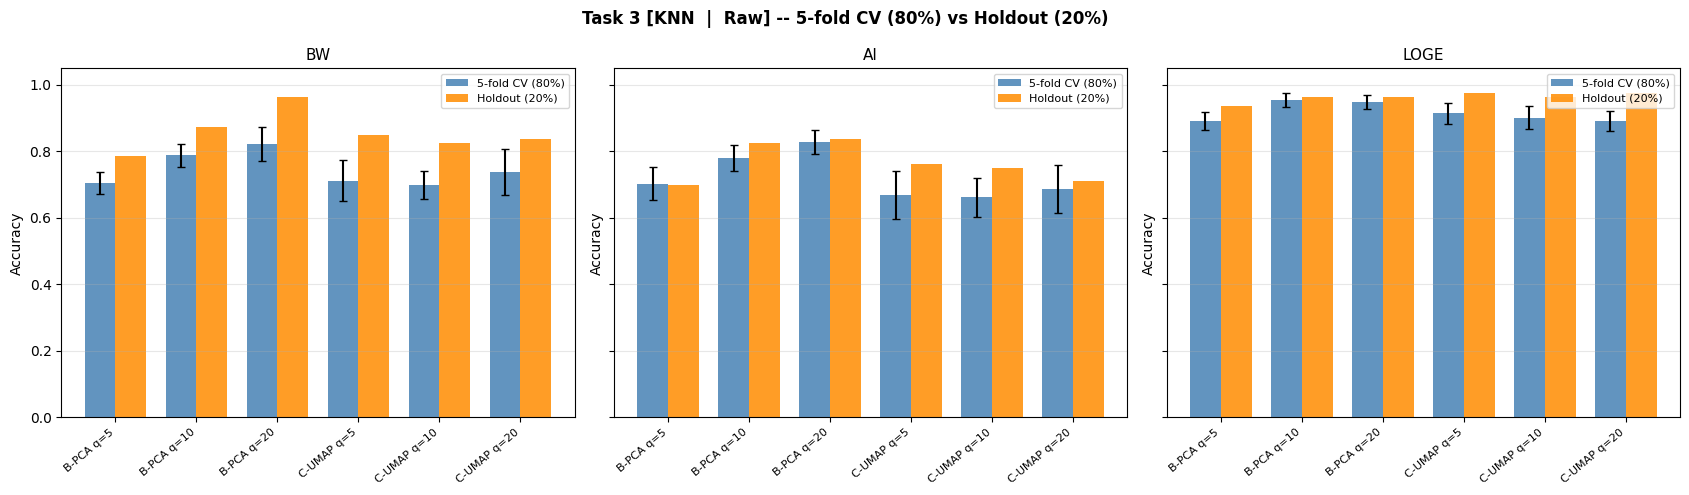

Saved: results_holdout/task3_holdout_knn_raw.png


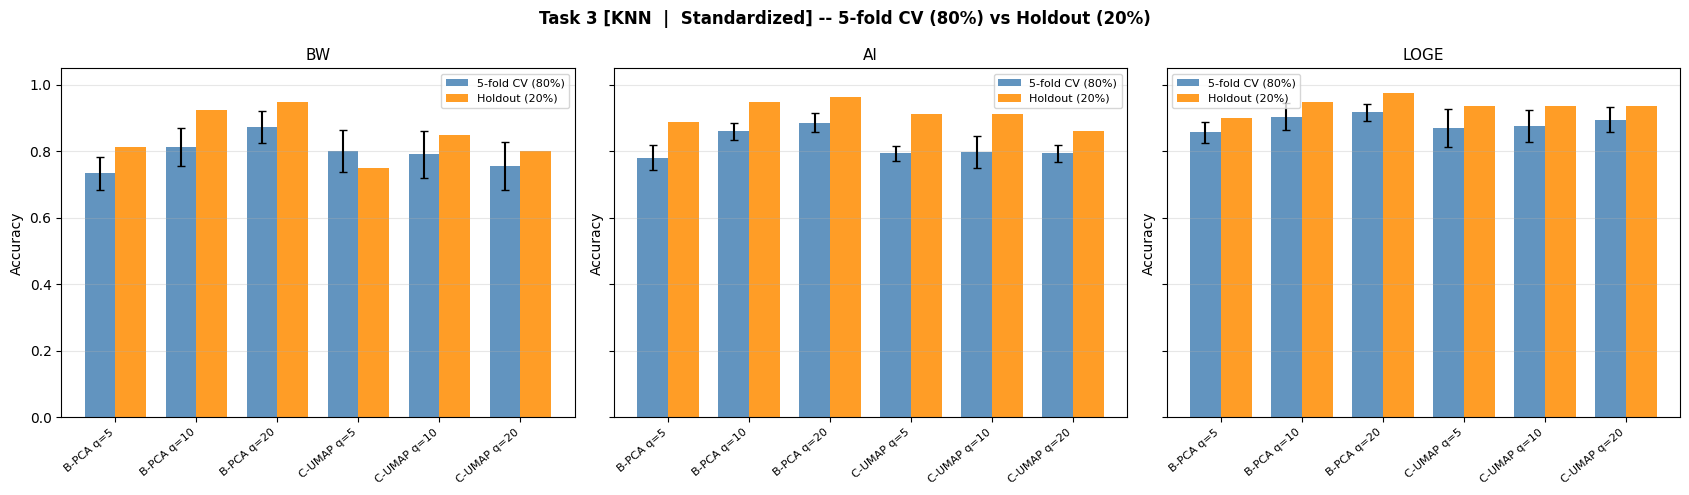

Saved: results_holdout/task3_holdout_knn_standardized.png


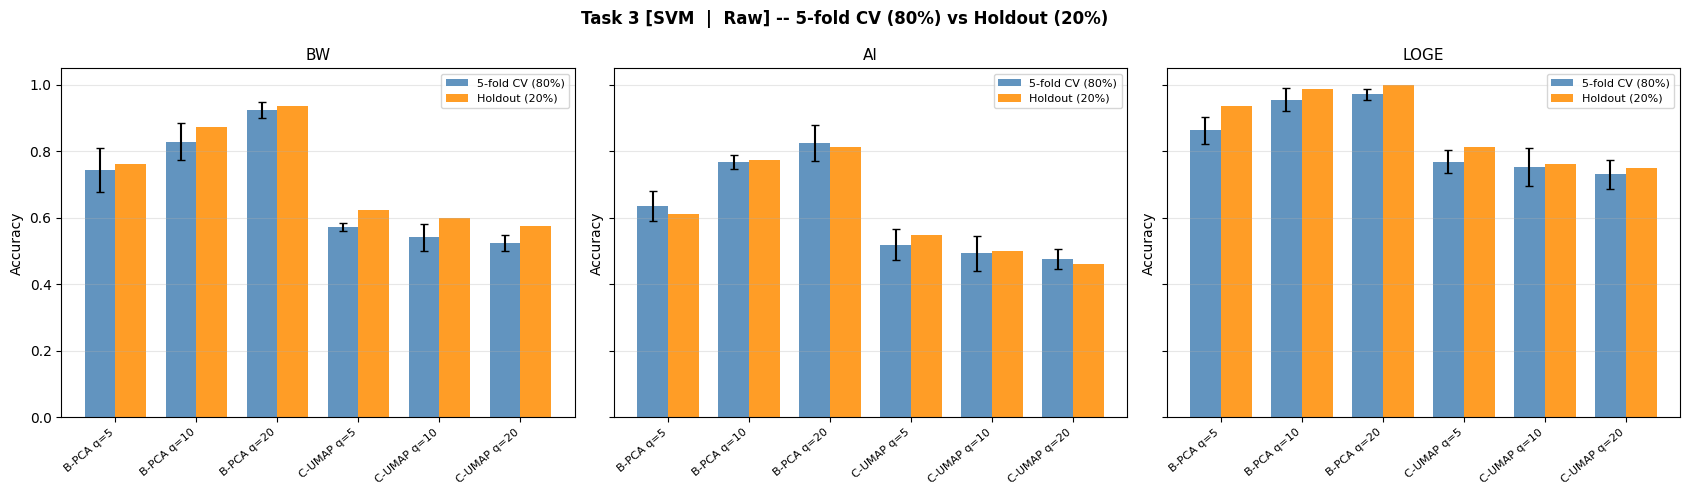

Saved: results_holdout/task3_holdout_svm_raw.png


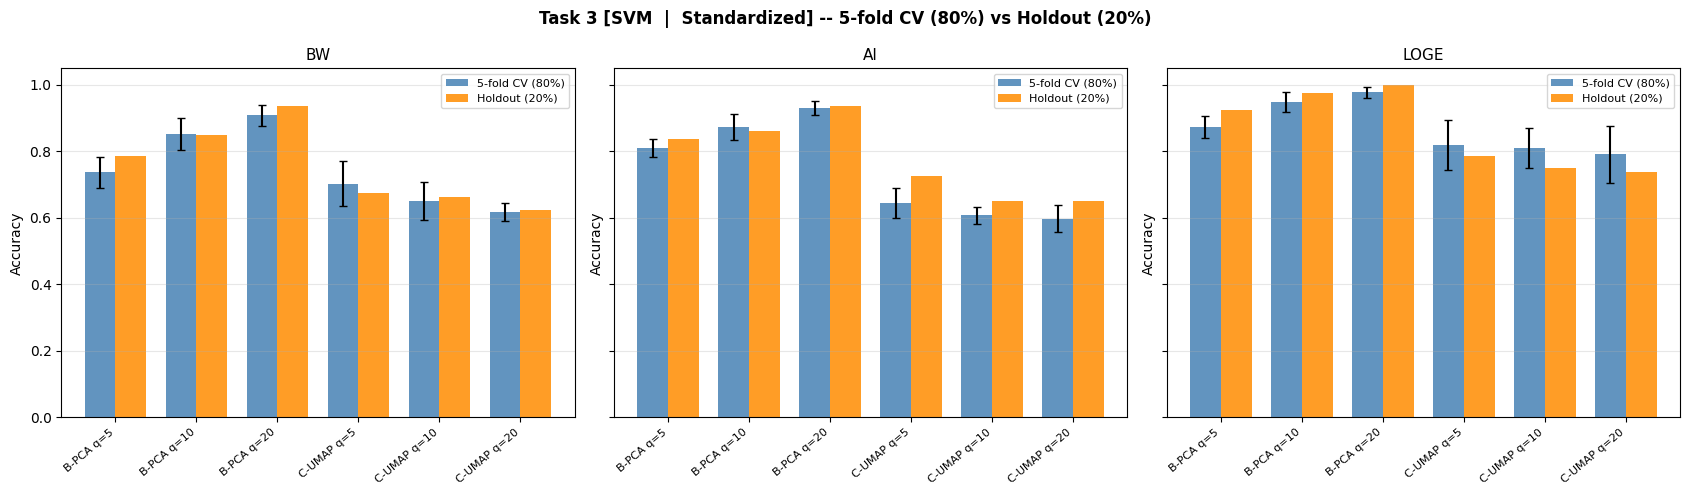

Saved: results_holdout/task3_holdout_svm_standardized.png


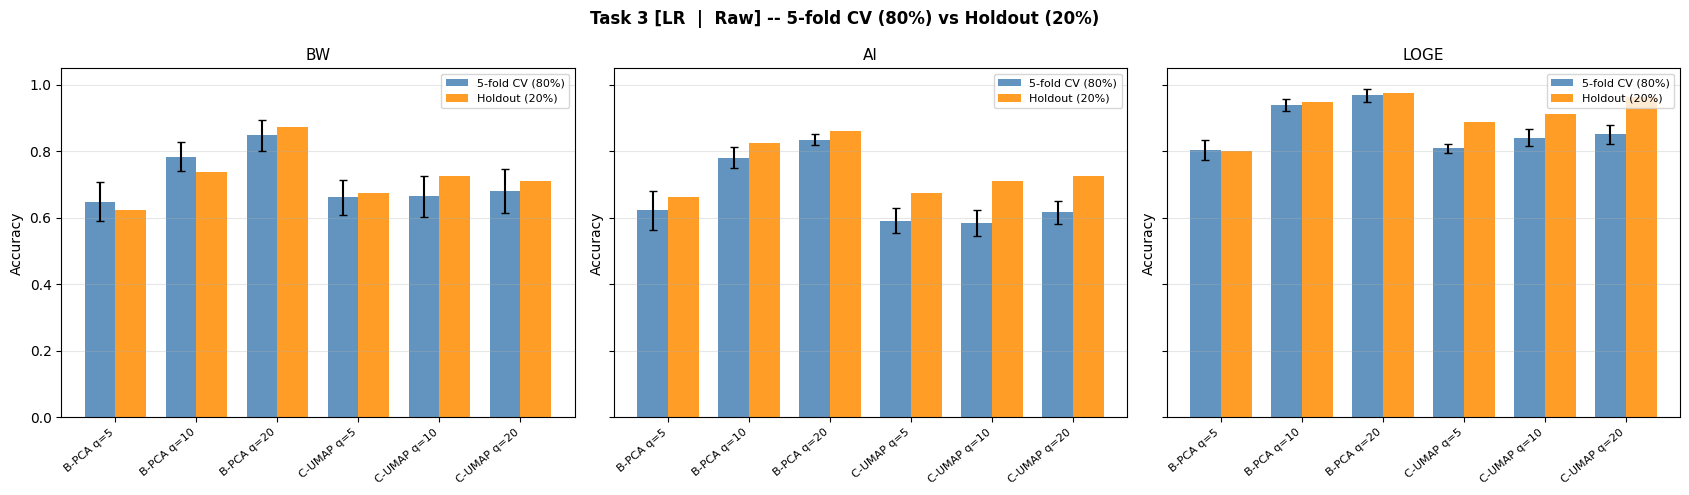

Saved: results_holdout/task3_holdout_lr_raw.png


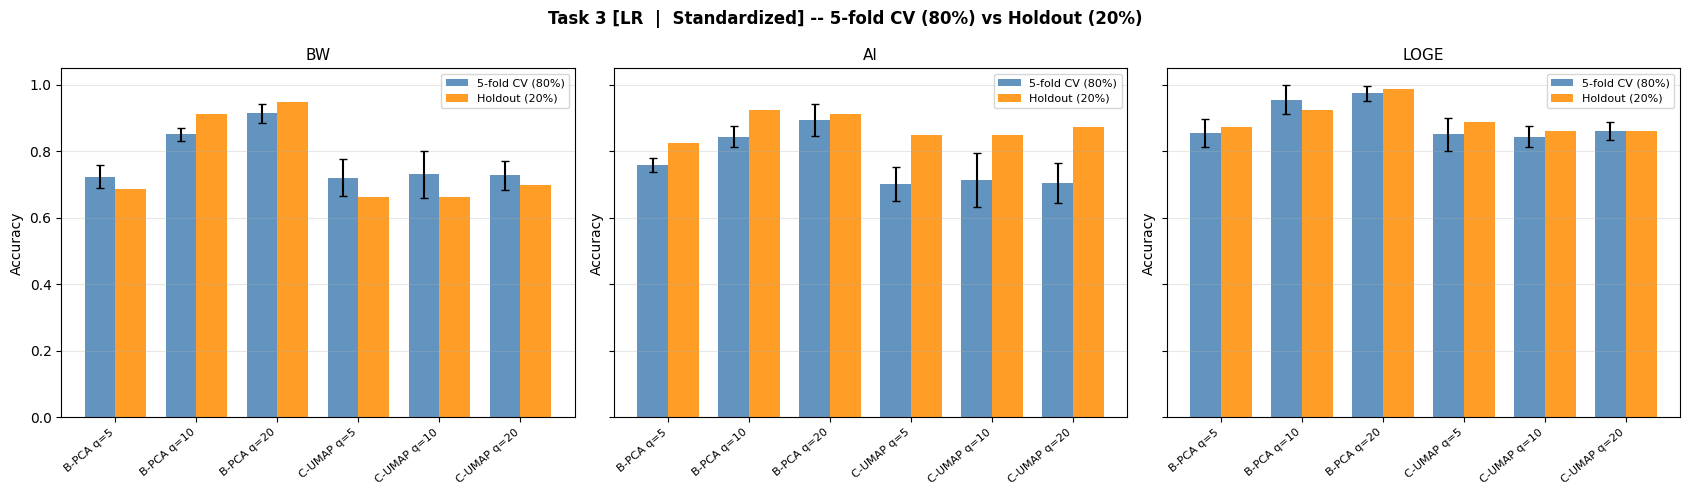

Saved: results_holdout/task3_holdout_lr_standardized.png


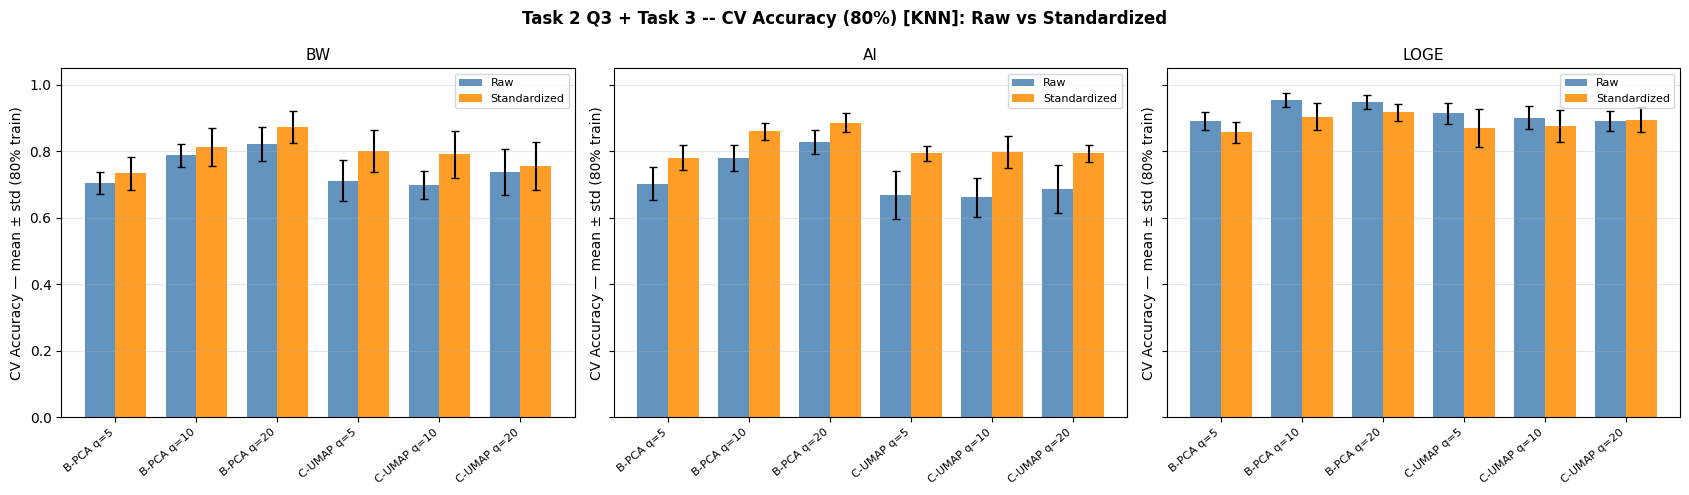

Saved: results_holdout/task3_cv_rawvsstd_knn.png


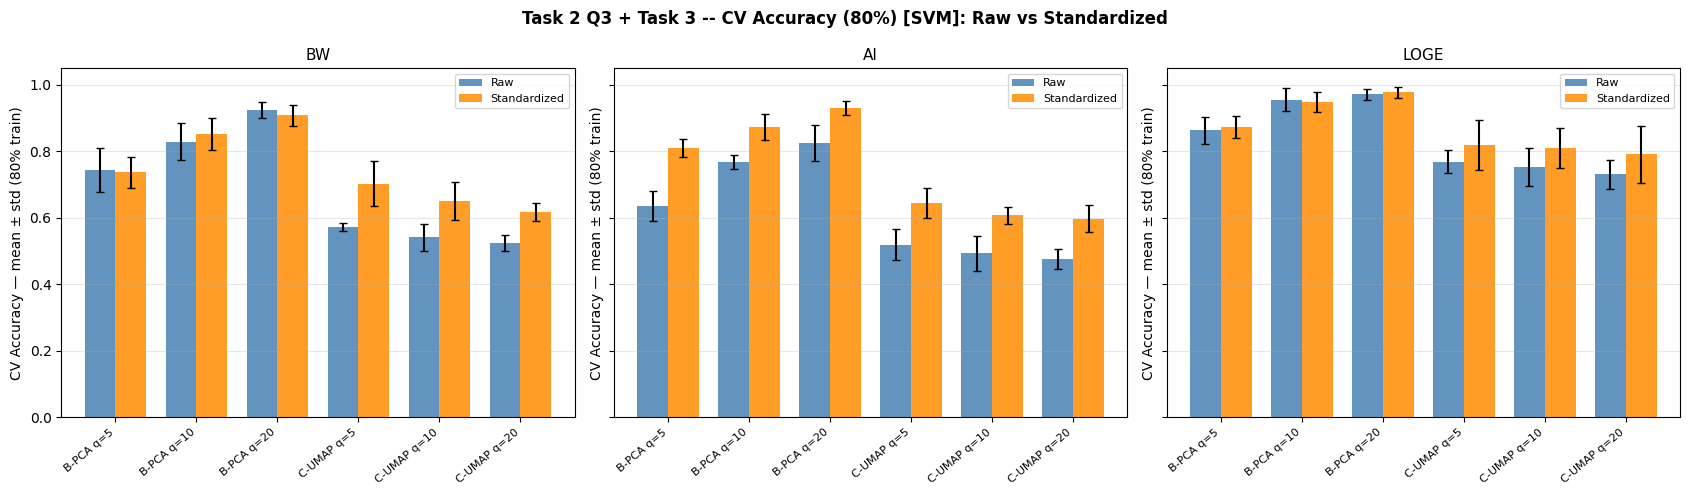

Saved: results_holdout/task3_cv_rawvsstd_svm.png


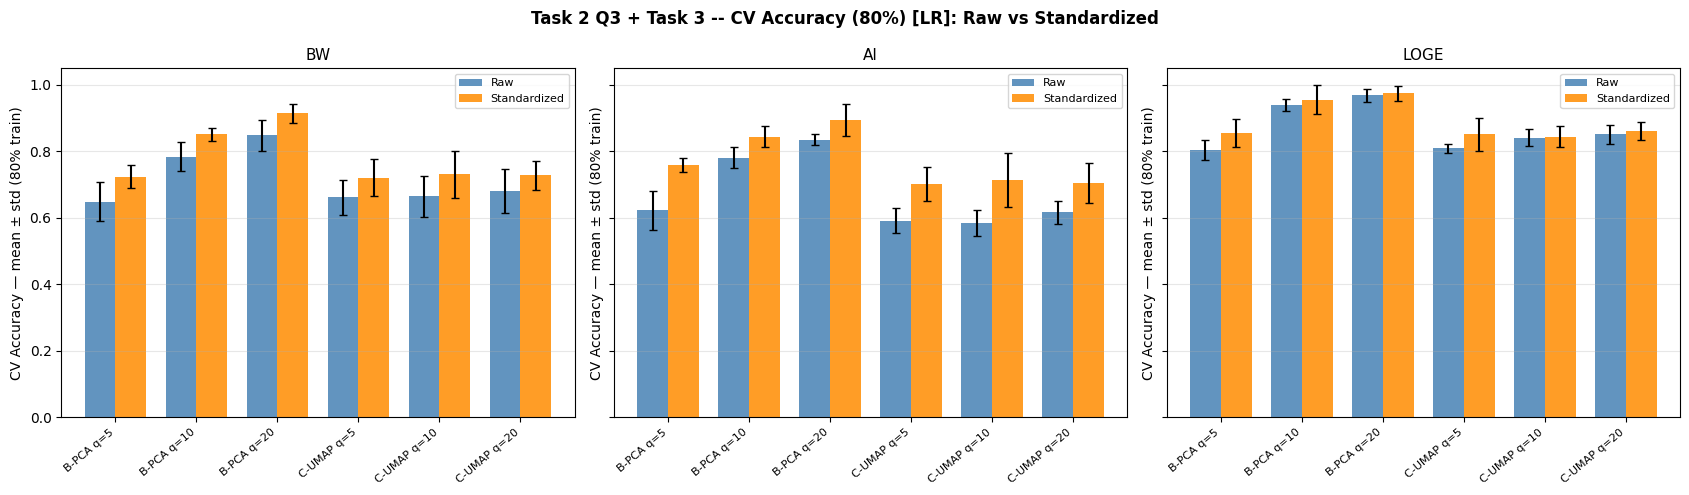

Saved: results_holdout/task3_cv_rawvsstd_lr.png

-- Best config per geometry (highest holdout accuracy) --
Geometry  Pipeline       q    Std  Clf     CV Acc   HO Acc
----------------------------------------------------------
BW        A-Full        --   True  lr      0.9653   1.0000
AI        A-Full        --   True  lr      0.9779   1.0000
LOGE      A-Full        --  False  lr      0.9874   1.0000


In [12]:
# Task 3 -- Plot A: CV vs Holdout accuracy ------------------------------------
# For each classifier × standardize setting: bars show 5-fold CV (80%) vs Holdout (20%)

for clf_name in CLASSIFIERS:
    df_clf = df_results[df_results["classifier"] == clf_name].copy()
    df_clf = df_clf[df_clf["pipeline"] != "A-Full"].copy()
    df_clf["label"] = df_clf.apply(
        lambda r: f"{r['pipeline']} q={int(r['q'])}", axis=1)

    label_order = [f"{pipe} q={q}"
                   for pipe in ["B-PCA", "C-UMAP"]
                   for q in Q_VALUES]

    for standardize, std_tag in [(False, "Raw"), (True, "Standardized")]:
        sub = df_clf[df_clf["standardize"] == standardize]
        if sub.empty:
            continue

        fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
        fig.suptitle(
            f"Task 3 [{clf_name.upper()}  |  {std_tag}] -- "
            f"5-fold CV (80%) vs Holdout (20%)",
            fontsize=12, fontweight="bold")

        for ax, metric in zip(axes, [m.upper() for m in METRICS]):
            sub_m = sub[sub["geometry"] == metric]
            x = np.arange(len(label_order))
            w = 0.38
            cv_accs, ho_accs, cv_errs = [], [], []
            for lbl in label_order:
                row = sub_m[sub_m["label"] == lbl]
                cv_accs.append(row["cv_accuracy"].values[0] if len(row) else 0)
                cv_errs.append(row["cv_acc_std"].values[0]  if len(row) else 0)
                ho_accs.append(row["ho_accuracy"].values[0] if len(row) else 0)

            ax.bar(x - w/2, cv_accs, w, yerr=cv_errs, capsize=3,
                   label="5-fold CV (80%)", color="steelblue",  alpha=0.85)
            ax.bar(x + w/2, ho_accs, w,
                   label="Holdout (20%)",  color="darkorange", alpha=0.85)
            ax.set_xticks(x)
            ax.set_xticklabels(label_order, rotation=40, ha="right", fontsize=8)
            ax.set_title(f"{metric}", fontsize=11)
            ax.set_ylabel("Accuracy")
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=8)
            ax.grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        fname = f"task3_holdout_{clf_name}_{std_tag.lower()}.png"
        plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {OUTPUT_DIR}/{fname}")

# Task 3 -- Plot B: CV accuracy — Raw vs Standardized  (matches original notebook)
# For each classifier: bars show Raw vs Standardized CV accuracy across pipelines/q

for clf_name in CLASSIFIERS:
    df_clf = df_results[df_results["classifier"] == clf_name].copy()
    df_clf = df_clf[df_clf["pipeline"] != "A-Full"].copy()
    df_clf["label"] = df_clf.apply(
        lambda r: f"{r['pipeline']} q={int(r['q'])}", axis=1)

    label_order = [f"{pipe} q={q}"
                   for pipe in ["B-PCA", "C-UMAP"]
                   for q in Q_VALUES]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
    fig.suptitle(
        f"Task 2 Q3 + Task 3 -- CV Accuracy (80%) [{clf_name.upper()}]: Raw vs Standardized",
        fontsize=12, fontweight="bold")

    for ax, metric in zip(axes, [m.upper() for m in METRICS]):
        sub = df_clf[df_clf["geometry"] == metric]
        x   = np.arange(len(label_order))
        w   = 0.38
        raw_accs, std_accs, raw_errs, std_errs = [], [], [], []
        for lbl in label_order:
            r = sub[(sub["label"] == lbl) & (~sub["standardize"])]
            raw_accs.append(r["cv_accuracy"].values[0] if len(r) else 0)
            raw_errs.append(r["cv_acc_std"].values[0]  if len(r) else 0)
            s = sub[(sub["label"] == lbl) & (sub["standardize"])]
            std_accs.append(s["cv_accuracy"].values[0] if len(s) else 0)
            std_errs.append(s["cv_acc_std"].values[0]  if len(s) else 0)

        ax.bar(x - w/2, raw_accs, w, yerr=raw_errs, capsize=3,
               label="Raw",          color="steelblue",  alpha=0.85)
        ax.bar(x + w/2, std_accs, w, yerr=std_errs, capsize=3,
               label="Standardized", color="darkorange",  alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(label_order, rotation=40, ha="right", fontsize=8)
        ax.set_title(f"{metric}", fontsize=11)
        ax.set_ylabel("CV Accuracy — mean ± std (80% train)")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    fname = f"task3_cv_rawvsstd_{clf_name}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/{fname}")

# -- Best configuration per geometry (by holdout accuracy) --------------------
print("\n-- Best config per geometry (highest holdout accuracy) --")
print(f"{'Geometry':<8}  {'Pipeline':<10}  {'q':>4}  {'Std':>5}  {'Clf':<5}  "
      f"{'CV Acc':>7}  {'HO Acc':>7}")
print("-" * 58)
for metric in [m.upper() for m in METRICS]:
    sub  = df_results[df_results["geometry"] == metric]
    best = sub.loc[sub["ho_accuracy"].idxmax()]
    q_val = best["q"]
    q_str = "--" if (q_val is None or
                     (isinstance(q_val, float) and np.isnan(q_val))) else str(int(q_val))
    print(f"{metric:<8}  {best['pipeline']:<10}  {q_str:>4}  "
          f"{str(best['standardize']):>5}  {best['classifier']:<5}  "
          f"{best['cv_accuracy']:>7.4f}  {best['ho_accuracy']:>7.4f}")


In [13]:
# Task 3 -- Top-5 models for full-dataset run ---------------------------------
# Ranked by holdout accuracy (20% test set).
# These configs will be re-run on the full / larger dataset.

top5 = (df_results
        .sort_values("ho_accuracy", ascending=False)
        .head(5)
        [["geometry", "pipeline", "q", "standardize", "classifier",
          "cv_accuracy", "cv_acc_std", "ho_accuracy", "ho_precision",
          "ho_recall",  "ho_auc"]]
        .reset_index(drop=True))

print("=" * 70)
print("TOP-5 CONFIGURATIONS TO RE-RUN ON THE FULL DATASET")
print("Ranked by holdout accuracy (20% test, trained on 80% of X_small)")
print("=" * 70)
print(top5.to_string(index=True,
      float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# Save as JSON so the configs can be loaded directly when running on X_full
import json as _json

best5_configs = []
for _, row in top5.iterrows():
    q_val = row["q"]
    cfg = {
        "rank":         int(_.real if hasattr(_.real, "__float__") else _) + 1,
        "geometry":     row["geometry"],
        "pipeline":     row["pipeline"],
        "q":            None if (q_val is None or
                                  (isinstance(q_val, float) and np.isnan(q_val)))
                             else int(q_val),
        "standardize":  bool(row["standardize"]),
        "classifier":   row["classifier"],
        "cv_accuracy":  round(float(row["cv_accuracy"]),  4),
        "cv_acc_std":   round(float(row["cv_acc_std"]),   4),
        "ho_accuracy":  round(float(row["ho_accuracy"]),  4),
        "ho_precision": round(float(row["ho_precision"]), 4),
        "ho_recall":    round(float(row["ho_recall"]),    4),
        "ho_auc":       round(float(row["ho_auc"]),       4),
    }
    best5_configs.append(cfg)

with open(os.path.join(OUTPUT_DIR, "best5_configs.json"), "w") as _f:
    _json.dump(best5_configs, _f, indent=2)

print("\nSaved: best5_configs.json")
print("\nTo re-run these on a larger dataset, load the configs and call:")
print("  run_holdout_cv(X_train80_large, y_train80_large,")
print("                 X_test20_large,  y_test20_large,")
print("                 metric=cfg['geometry'].lower(),")
print("                 pipeline=cfg['pipeline'][0],   # 'A', 'B', or 'C'")
print("                 q=cfg['q'] or 10,")
print("                 standardize=cfg['standardize'],")
print("                 classifier=cfg['classifier'])")

TOP-5 CONFIGURATIONS TO RE-RUN ON THE FULL DATASET
Ranked by holdout accuracy (20% test, trained on 80% of X_small)
  geometry pipeline       q  standardize classifier  cv_accuracy  cv_acc_std  ho_accuracy  ho_precision  ho_recall  ho_auc
0       AI   A-Full     NaN         True         lr       0.9779      0.0161       1.0000        1.0000     1.0000  1.0000
1       BW   A-Full     NaN         True         lr       0.9653      0.0208       1.0000        1.0000     1.0000  1.0000
2     LOGE    B-PCA 20.0000        False        svm       0.9715      0.0155       1.0000        1.0000     1.0000  1.0000
3     LOGE    B-PCA 20.0000         True        svm       0.9779      0.0160       1.0000        1.0000     1.0000  1.0000
4     LOGE   A-Full     NaN        False        svm       0.9937      0.0077       1.0000        1.0000     1.0000  1.0000

Saved: best5_configs.json

To re-run these on a larger dataset, load the configs and call:
  run_holdout_cv(X_train80_large, y_train80_large,
   

In [ ]:
# Load and review best5_configs.json -----------------------------------------
# Run this any time after Task 3 to review the saved top-5 configs.
# The full dataset notebook reads this file automatically.

import json

_path = os.path.join(OUTPUT_DIR, "best5_configs.json")
with open(_path) as f:
    best5 = json.load(f)

print("=" * 65)
print(f"TOP-5 CONFIGS  ({_path})")
print("=" * 65)
print(f"{'Rk':<3}  {'Geometry':<8}  {'Pipeline':<10}  {'q':>4}  "
      f"{'Std':>5}  {'Clf':<5}  {'CV Acc':>7}  {'HO Acc':>7}  {'AUC':>7}")
print("-" * 65)
for cfg in best5:
    q_str = "--" if cfg["q"] is None else str(cfg["q"])
    print(f"  {cfg['rank']:<3}  {cfg['geometry']:<8}  {cfg['pipeline']:<10}  "
          f"{q_str:>4}  {str(cfg['standardize']):>5}  {cfg['classifier']:<5}  "
          f"{cfg['cv_accuracy']:>7.4f}  {cfg['ho_accuracy']:>7.4f}  "
          f"{cfg['ho_auc']:>7.4f}")

print(f"\nTo use these in spd_geometry_full_dataset.ipynb:")
print(f"  Run the 'Re-run top-5 models from holdout notebook' cell.")
print(f"  It loads this file from  {_path}")
